<a href="https://colab.research.google.com/github/ankan-git-coder/computer_vision/blob/main/R_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install torch_snippets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.3/110.3 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.7/184.7 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.5/226.5 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.2/398.2 kB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.4/99.4 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 99.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 469.2/469.2 kB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 76.9 MB/s eta 0:00:00
 

In [4]:
from torch_snippets import logger ,show

In [6]:
pip install opencv-contrib-python

In [8]:
pip install selectivesearch

  Preparing metadata (setup.py) ... done
  Created wheel for selectivesearch: filename=selectivesearch-0.4-py3-none-any.whl size=4336 sha256=f20ffef99d22bc0720c360f2369723e1b276b038629960eea09e91ddba2a95c4
  Stored in directory: /root/.cache/pip/wheels/7f/9b/c7/58b71f1e9fe4aa0ef8affd1c673f8818bc22a5091ea8cbbe93
Successfully built selectivesearch


In [9]:
import selectivesearch
from torchvision import transforms , models , datasets
from torchvision.ops import nms
import numpy as np
import pandas as pd
import cv2
from torch.utils.data import Dataset

In [10]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sixhky/open-images-bus-trucks")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'open-images-bus-trucks' dataset.
Path to dataset files: /kaggle/input/open-images-bus-trucks


In [11]:
import os

print(os.listdir(path))

['images', 'df.csv']


In [12]:
for root, dirs, files in os.walk(path):
    print(root)
    print(files[:5])   # First 5 files

/kaggle/input/open-images-bus-trucks
['df.csv']
/kaggle/input/open-images-bus-trucks/images
[]
/kaggle/input/open-images-bus-trucks/images/images
['71101ab7a0c4ded8.jpg', 'de79fae7547caac9.jpg', '8324b0240d830b82.jpg', '5b986c3b2e95a07c.jpg', '87d8fe93cb15123e.jpg']


In [13]:

df = pd.read_csv(path + "/df.csv")
print(df.head())
print(df.columns)

            ImageID  Source LabelName  ...  XClick2Y  XClick3Y  XClick4Y
0  0000599864fd15b3  xclick       Bus  ...  0.512700  0.650047  0.457197
1  00006bdb1eb5cd74  xclick     Truck  ...  0.241855  0.352130  0.437343
2  00006bdb1eb5cd74  xclick     Truck  ...  0.398496  0.409774  0.295739
3  00010bf498b64bab  xclick       Bus  ...  0.493882  0.705228  0.521691
4  00013f14dd4e168f  xclick       Bus  ...  0.303940  0.999062  0.523452

[5 rows x 21 columns]
Index(['ImageID', 'Source', 'LabelName', 'Confidence', 'XMin', 'XMax', 'YMin',
       'YMax', 'IsOccluded', 'IsTruncated', 'IsGroupOf', 'IsDepiction',
       'IsInside', 'XClick1X', 'XClick2X', 'XClick3X', 'XClick4X', 'XClick1Y',
       'XClick2Y', 'XClick3Y', 'XClick4Y'],
      dtype='object')


In [15]:


image_dir = path + "/images"
print(os.listdir(image_dir)[:5])

['images']


In [18]:


for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith((".jpg", ".jpeg", ".png")):
            print("IMAGE FOUND IN:", root)
            print("Sample file:", file)
            break

IMAGE FOUND IN: /kaggle/input/open-images-bus-trucks/images/images
Sample file: 71101ab7a0c4ded8.jpg


In [26]:
IMAGE_ROOT = "/kaggle/input/open-images-bus-trucks/images/images"

In [27]:
DF_RAW = pd.read_csv('/kaggle/input/open-images-bus-trucks/df.csv')

In [29]:
print(IMAGE_ROOT)

/kaggle/input/open-images-bus-trucks/images/images


In [30]:
print(DF_RAW.head())

            ImageID  Source LabelName  ...  XClick2Y  XClick3Y  XClick4Y
0  0000599864fd15b3  xclick       Bus  ...  0.512700  0.650047  0.457197
1  00006bdb1eb5cd74  xclick     Truck  ...  0.241855  0.352130  0.437343
2  00006bdb1eb5cd74  xclick     Truck  ...  0.398496  0.409774  0.295739
3  00010bf498b64bab  xclick       Bus  ...  0.493882  0.705228  0.521691
4  00013f14dd4e168f  xclick       Bus  ...  0.303940  0.999062  0.523452

[5 rows x 21 columns]


In [33]:
class OpenImages(Dataset):
    def __init__(self, df, image_folder=IMAGE_ROOT):
        self.root = image_folder
        self.df = df
        self.unique_images = df['ImageID'].unique()
    def __len__(self):
       return len(self.unique_images)
    def __getitem__(self, ix):
        image_id = self.unique_images[ix]
        image_path = f'{self.root}/{image_id}.jpg'
        image = cv2.imread(image_path, 1)[...,::-1] # convert BGR to RGB
        h, w, _ = image.shape
        df = self.df.copy()
        df = df[df['ImageID'] == image_id]
        boxes = df['XMin,YMin,XMax,YMax'.split(',')].values
        boxes = (boxes * np.array([w,h,w,h])).astype(np.uint16).tolist() #boxes in accordance to the image
        classes = df['LabelName'].values.tolist()
        return image, boxes, classes, image_path
ds = OpenImages(df=DF_RAW)

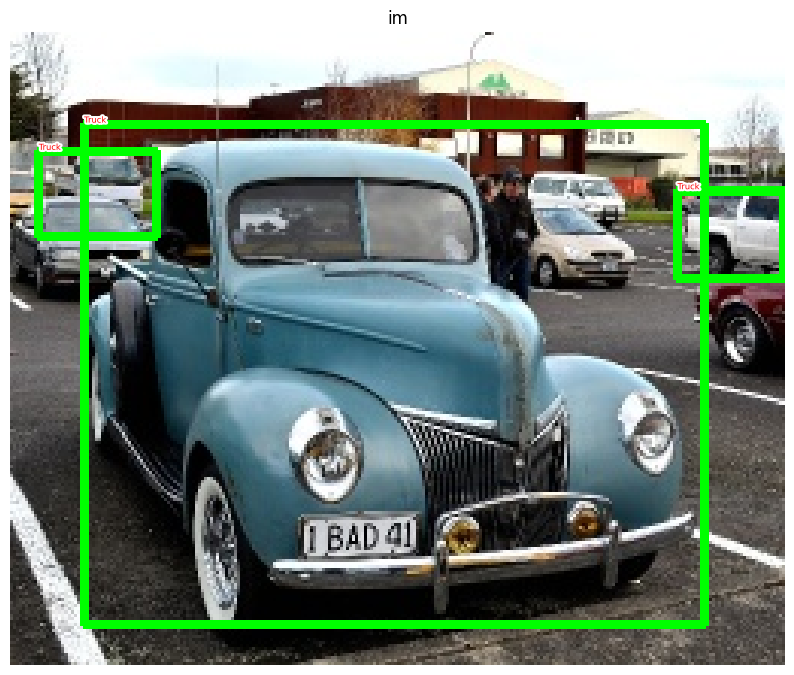

[[9, 39, 48, 67], [24, 30, 229, 195], [220, 52, 255, 81]]


In [34]:
im, bbs, clss, _ = ds[6]
show(im, bbs=bbs, texts=clss, sz=10)
print(bbs)

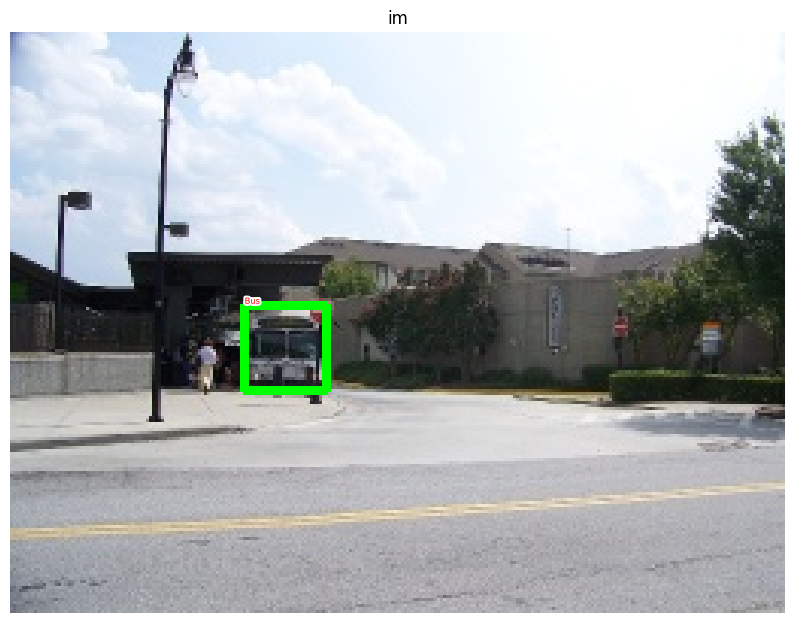

[[77, 90, 104, 118]]


In [35]:
im, bbs, clss, _ = ds[15]
show(im, bbs=bbs, texts=clss, sz=10)
print(bbs)